In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
df = pd.read_csv('/content/loan_applications.csv')

In [ ]:
df.head()

,Customer_ID,Age,Income,Loan_Amount,Credit_Score,Loan_Term,Default_Status
0,CUST100000,59,117603.41,192209.53,588,60,No
1,CUST100001,49,110648.97,145330.71,626,72,Yes
2,CUST100002,35,125469.51,133442.91,715,84,No
3,CUST100003,63,66023.87,128296.57,712,24,No
4,CUST100004,28,77390.61,146226.37,604,36,No


In [ ]:
df.tail()

,Customer_ID,Age,Income,Loan_Amount,Credit_Score,Loan_Term,Default_Status
4995,CUST104995,33,88614.66,109727.34,661,12,No
4996,CUST104996,65,86048.68,140322.87,671,36,No
4997,CUST104997,37,63243.31,232336.73,569,24,Yes
4998,CUST104998,57,75442.96,179782.90,713,48,No
4999,CUST104999,26,49383.74,85231.56,705,60,No


In [ ]:
df.shape

(5000, 7)

In [ ]:
df.columns

Index(['Customer_ID', 'Age', 'Income', 'Loan_Amount', 'Credit_Score',
       'Loan_Term', 'Default_Status'],
      dtype='object')

In [ ]:
df.nunique()

,0
Customer_ID,5000
Age,45
Income,4859
Loan_Amount,4961
Credit_Score,418
Loan_Term,7
Default_Status,2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Customer_ID     5000 non-null   object 
 1   Age             5000 non-null   int64  
 2   Income          5000 non-null   float64
 3   Loan_Amount     5000 non-null   float64
 4   Credit_Score    5000 non-null   int64  
 5   Loan_Term       5000 non-null   int64  
 6   Default_Status  5000 non-null   object 
dtypes: float64(2), int64(3), object(2)
memory usage: 273.6+ KB


In [ ]:
df.isnull().sum()

,0
Customer_ID,0
Age,0
Income,0
Loan_Amount,0
Credit_Score,0
Loan_Term,0
Default_Status,0


In [ ]:
missing_values = df.isnull().sum()

missing_percentage = (
    missing_values / len(df)
) * 100

missing_data = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
})

missing_data

,Missing Values,Percentage
Customer_ID,0,0.0
Age,0,0.0
Income,0,0.0
Loan_Amount,0,0.0
Credit_Score,0,0.0
Loan_Term,0,0.0
Default_Status,0,0.0


In [ ]:
df.duplicated().sum()

np.int64(0)

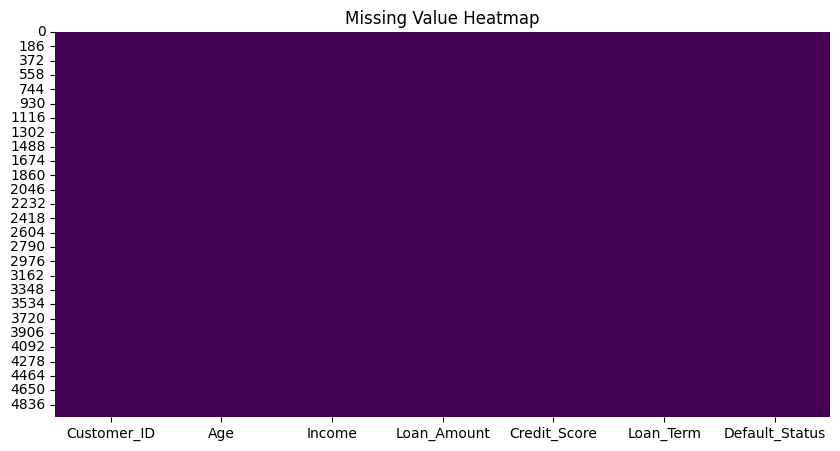

In [ ]:
plt.figure(figsize=(10,5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap='viridis'
)

plt.title('Missing Value Heatmap')

plt.show()

In [ ]:
df.describe()

,Age,Income,Loan_Amount,Credit_Score,Loan_Term
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.13460,69526.377984,150192.741294,680.889600,48.158400
std,12.89329,24879.055207,58694.914864,88.605232,23.865876
min,21.00000,20000.000000,5000.000000,352.000000,12.000000
25%,32.00000,51989.962500,110944.972500,620.000000,24.000000
50%,43.00000,69236.880000,149598.090000,683.000000,48.000000
75%,54.00000,86695.617500,189273.637500,744.000000,72.000000
max,65.00000,168155.940000,352666.090000,850.000000,84.000000


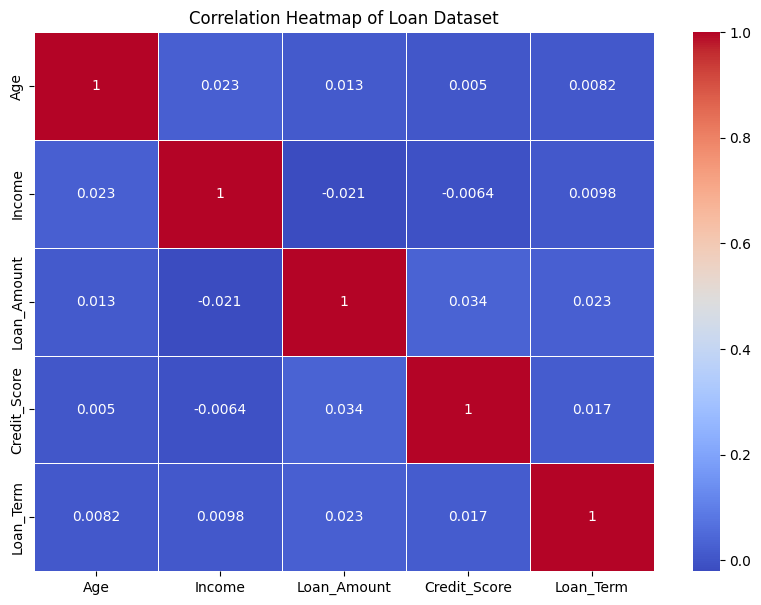

In [ ]:
plt.figure(figsize=(10,7))
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlation Heatmap of Loan Dataset')

plt.show()

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

numeric_df.corr()

,Age,Income,Loan_Amount,Credit_Score,Loan_Term
Age,1.000000,0.023358,0.012965,0.004994,0.008184
Income,0.023358,1.000000,-0.020673,-0.006418,0.009813
Loan_Amount,0.012965,-0.020673,1.000000,0.034267,0.023356
Credit_Score,0.004994,-0.006418,0.034267,1.000000,0.017432
Loan_Term,0.008184,0.009813,0.023356,0.017432,1.000000


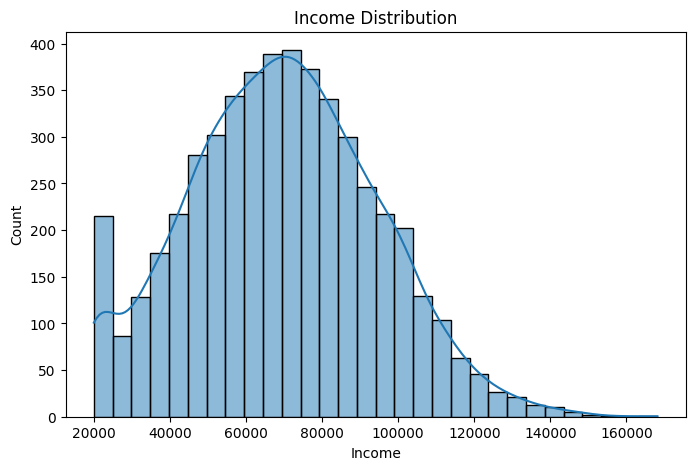

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Income'],
    kde=True,
    bins=30
)

plt.title('Income Distribution')

plt.show()

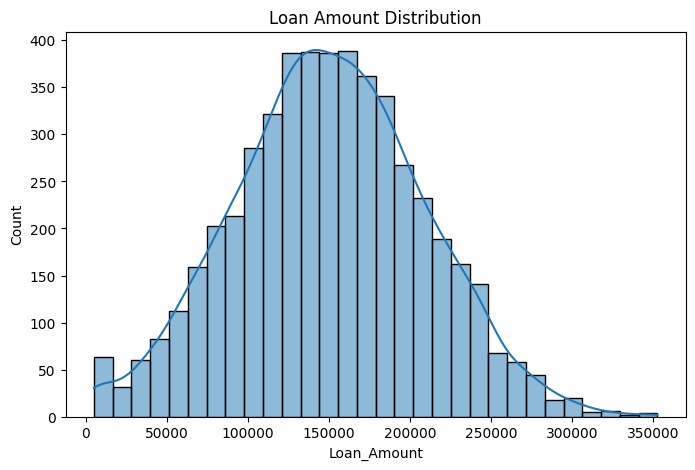

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Loan_Amount'],
    kde=True,
    bins=30
)

plt.title('Loan Amount Distribution')

plt.show()


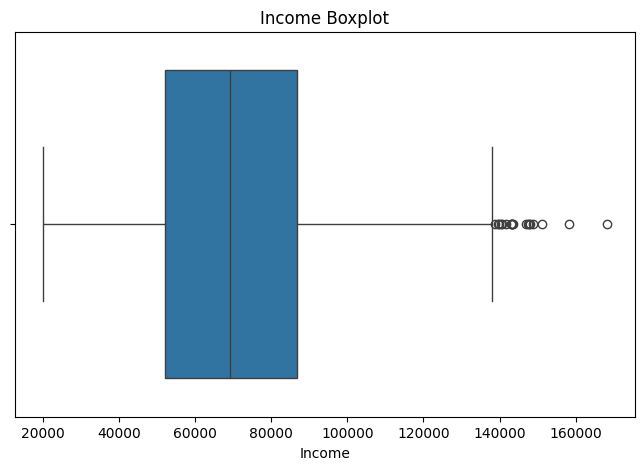

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['Income']
)

plt.title('Income Boxplot')

plt.show()

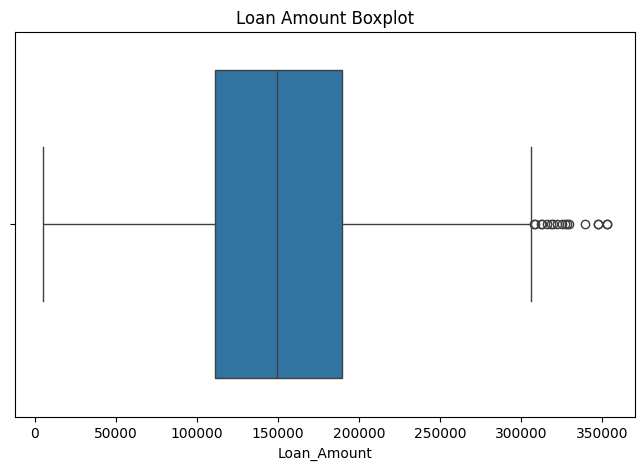

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['Loan_Amount']
)

plt.title('Loan Amount Boxplot')

plt.show()

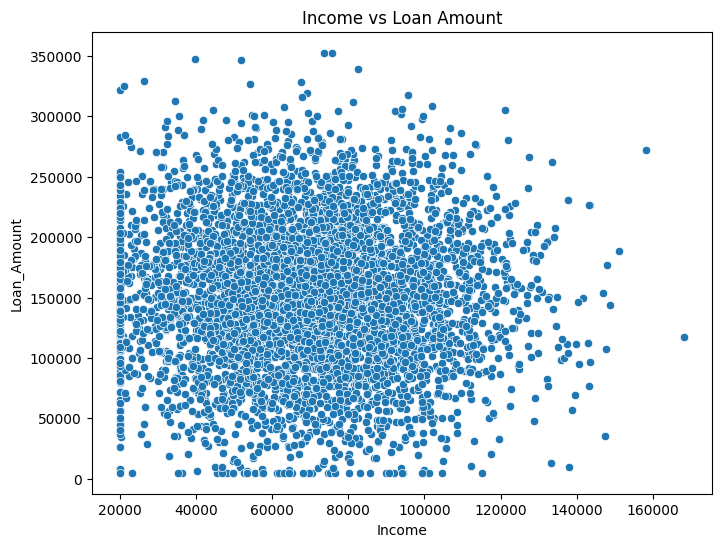

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['Income'],
    y=df['Loan_Amount']
)

plt.title('Income vs Loan Amount')

plt.show()

/tmp/ipykernel_1720/923783508.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


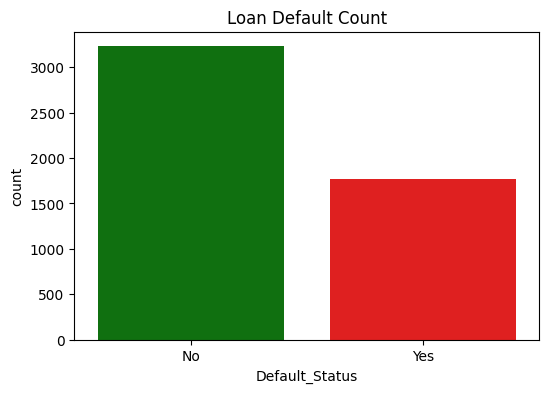

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Default_Status',
    data=df,
    palette=['green', 'red']
)

plt.title('Loan Default Count')

plt.show()

The Mean represents the average income of all customers in the dataset. It is calculated by adding all customer incomes together and dividing by the total number of customers. Mean helps understand the general earning level of loan applicants. It provides a central value around which most income values are distributed.

In [ ]:
mean_income = df['Income'].mean()
print("Mean Income:", mean_income)

Mean Income: 69526.37798399999


The Median is the middle value of the income data after arranging all values in ascending order. It divides the dataset into two equal parts:

50% values above median
50% values below median

Median is very useful when the dataset contains outliers because it is not heavily affected by extremely large or small values. Therefore, it often gives a more realistic representation of the typical customer income compared to the mean.

In [ ]:
median_income = df['Income'].median()
print("Median Income:", median_income)

Median Income: 69236.88


The Mode is the most frequently occurring income value in the dataset. It represents the income value that appears most often among customers. Mode is useful for identifying the most common customer behavior or financial pattern.

In [ ]:
mode_income = df['Income'].mode()[0]
print("Mode Income:", mode_income)

Mode Income: 20000.0


The Range is the difference between the maximum value and minimum value in a dataset. It is the simplest measure of dispersion and shows the total spread of the data.

Range=Maximum Value−Minimum Value

In [ ]:
range_loan = df['Loan_Amount'].max() - df['Loan_Amount'].min()

print("Range of Loan Amount:", range_loan)

Range of Loan Amount: 347666.09


Variance measures how far each data value is from the mean. It calculates the average squared deviation from the mean. Variance helps determine whether the data values are concentrated around the average or widely dispersed.

In [ ]:
variance_loan = df['Loan_Amount'].var()

print("Variance of Loan Amount:", variance_loan)

Variance of Loan Amount: 3445093030.943966


Standard deviation is the square root of variance. It measures the average distance of data values from the mean. Unlike variance, standard deviation uses the same units as the original data, making it easier to interpret.

In [ ]:
std_loan = df['Loan_Amount'].std()

print("Standard Deviation:", std_loan)

Standard Deviation: 58694.91486444091


The Probability of Default measures the likelihood that a customer will fail to repay their loan. It is one of the most important concepts in banking, finance, and risk management because it helps financial institutions estimate the risk associated with giving loans to customers.

In [ ]:
default_probability = (df['Default_Status'] == 'Yes').mean()

print("Probability of Default:", default_probability)

Probability of Default: 0.354


In [ ]:
bins = [300, 600, 700, 850]
labels = ['Low', 'Medium', 'High']

df['Credit_Category'] = pd.cut(
    df['Credit_Score'],
    bins=bins,
    labels=labels
)

df.head()

,Customer_ID,Age,Income,Loan_Amount,Credit_Score,Loan_Term,Default_Status,Credit_Category
0,CUST100000,59,117603.41,192209.53,588,60,No,Low
1,CUST100001,49,110648.97,145330.71,626,72,Yes,Medium
2,CUST100002,35,125469.51,133442.91,715,84,No,High
3,CUST100003,63,66023.87,128296.57,712,24,No,High
4,CUST100004,28,77390.61,146226.37,604,36,No,Medium


A Contingency Table is used to show the relationship between two categorical variables. It displays the frequency (count) of combinations of categories.

In [ ]:
contingency_table = pd.crosstab(
    df['Credit_Category'],
    df['Default_Status']
)

print(contingency_table)

Default_Status     No  Yes
Credit_Category           
Low               317  594
Medium           1228  770
High             1685  406


Calculates probability of default for customers with low credit scores.

Purpose:

Identify risky customers
Evaluate financial risk

Higher probability:

Greater default risk

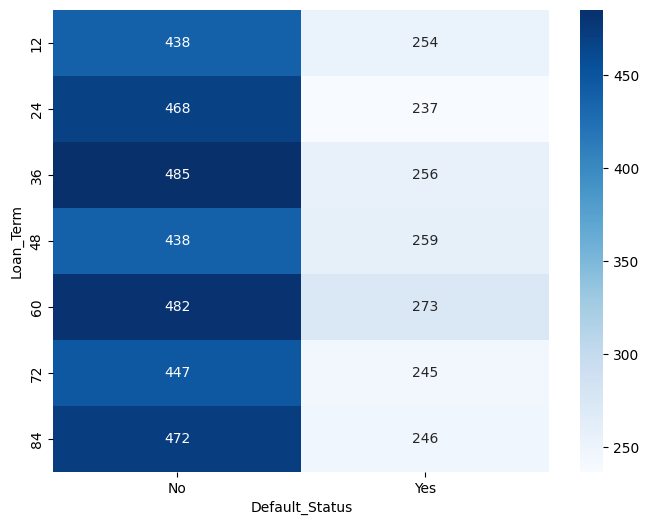

In [ ]:
contingency = pd.crosstab(
    df['Loan_Term'],
    df['Default_Status']
)

plt.figure(figsize=(8,6))

sns.heatmap(
    contingency,
    annot=True,
    cmap='Blues',
    fmt='d'
)

plt.show()

In [ ]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(contingency)

print(chi2)
print(p)

3.271004611578575
0.7741443787006534


In [ ]:
low_credit = df[df['Credit_Score'] < 600]

conditional_probability = (
    (low_credit['Default_Status'] == 'Yes').mean()
)

print("Conditional Probability:", conditional_probability)

Conditional Probability: 0.6621621621621622


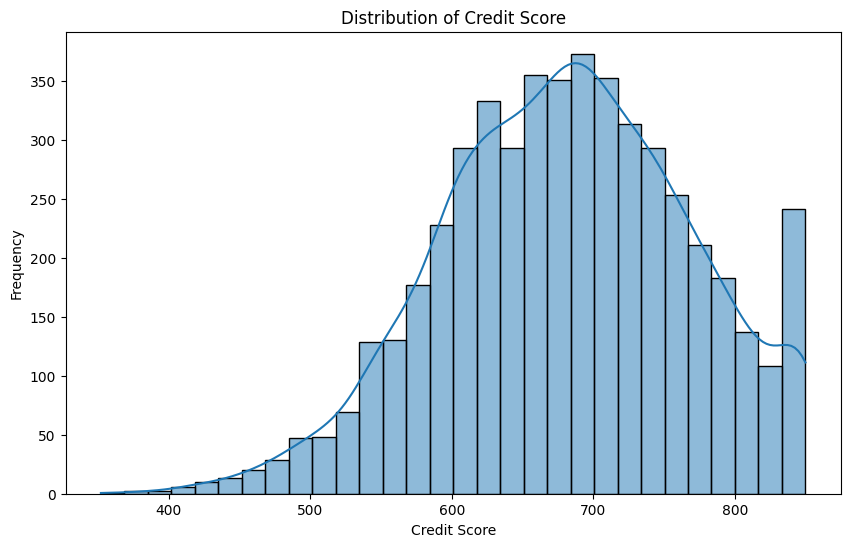

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['Credit_Score'],
    kde=True,
    bins=30
)

plt.title('Distribution of Credit Score')
plt.xlabel('Credit Score')
plt.ylabel('Frequency')

plt.show()

Compares actual distribution with normal distribution.
Detect normality
Analyze distribution shape

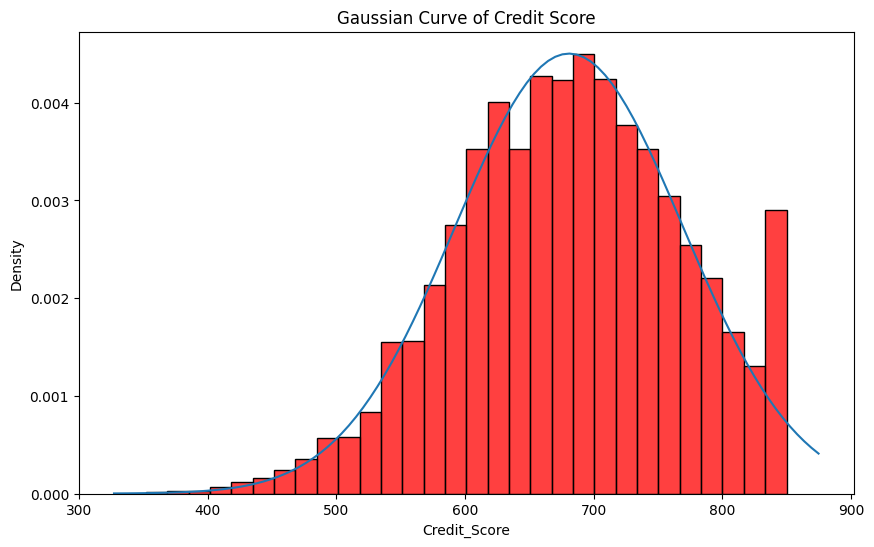

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['Credit_Score'],
    stat='density',
    bins=30,
    color='red'
)

mean = df['Credit_Score'].mean()
std = df['Credit_Score'].std()

xmin, xmax = plt.xlim()

x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mean, std)

plt.plot(x, p)

plt.title('Gaussian Curve of Credit Score')

plt.show()

Measures asymmetry in loan amount distribution.

Values:

Positive → right-skewed
Negative → left-skewed
Near 0 → symmetric

In [ ]:
skewness = df['Loan_Amount'].skew()

print("Skewness:", skewness)

Skewness: 0.04121102723857818


Measures heaviness of distribution tails.

High kurtosis:

More outliers
Extreme values present

In [ ]:
kurtosis = df['Loan_Amount'].kurtosis()

print("Kurtosis:", kurtosis)

Kurtosis: -0.1252409035277382


Checks whether income follows normal distribution.

If points lie near straight line:

Data is approximately normal

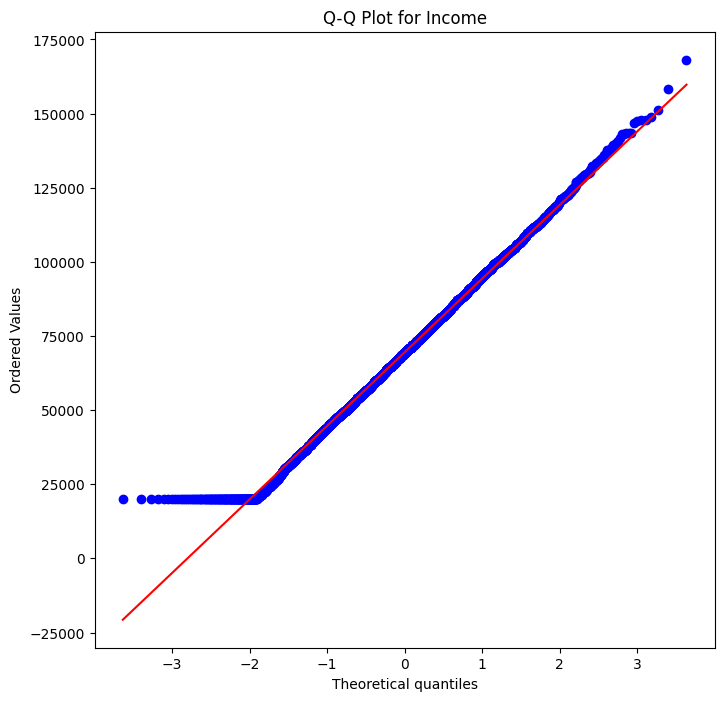

In [ ]:
import scipy.stats as stats

plt.figure(figsize=(8,8))

stats.probplot(
    df['Income'],
    dist="norm",
    plot=plt
)

plt.title('Q-Q Plot for Income')

plt.show()


Dot Product

Measures similarity between customer vectors.

In [ ]:
vectors = df[['Income', 'Loan_Amount']].head()

vectors

,Income,Loan_Amount
0,117603.41,192209.53
1,110648.97,145330.71
2,125469.51,133442.91
3,66023.87,128296.57
4,77390.61,146226.37


In [ ]:
v1 = vectors.iloc[0].values
v2 = vectors.iloc[1].values

dot_product = np.dot(v1, v2)

print("Dot Product:", dot_product)

Dot Product: 40946643648.654


Vector Norm

Measures magnitude of customer financial vector.

In [ ]:
norm_v1 = np.linalg.norm(v1)

print("Norm of Vector 1:", norm_v1)

Norm of Vector 1: 225333.2320507763


Angle Between Vectors

Measures similarity direction.

In [ ]:
cos_theta = dot_product / (
    np.linalg.norm(v1) * np.linalg.norm(v2)
)

angle = np.arccos(cos_theta)

angle_degrees = np.degrees(angle)

print("Angle Between Vectors:", angle_degrees)

Angle Between Vectors: 5.823808419524196


Compares actual distribution with normal distribution.
Detect normality
Analyze distribution shape

/tmp/ipykernel_1720/487156773.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(


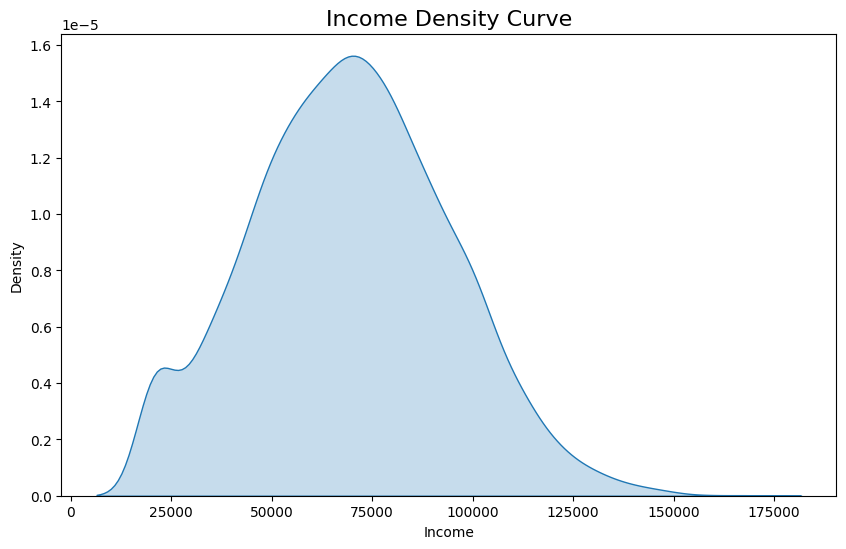

In [ ]:
plt.figure(figsize=(10,6))

sns.kdeplot(
    df['Income'],
    shade=True
)

plt.title(
    'Income Density Curve',
    fontsize=16
)

plt.show()

The loan default analysis project successfully examined customer financial data using statistics, probability, visualization, and linear algebra concepts. The analysis showed that factors such as income, credit score, and loan amount significantly affect loan default behavior. Customers with lower credit scores were found to have a higher probability of default.

Various EDA techniques like heatmaps, histograms, boxplots, scatter plots, and contingency tables helped identify important patterns and relationships in the dataset. Statistical measures such as mean, median, variance, and standard deviation provided insights into customer financial distribution and risk variability.

Overall, this project demonstrates how data analysis can help banks and financial institutions identify high-risk customers, improve loan approval decisions, reduce financial losses, and build future machine learning models for loan default prediction.